# StFT Plasma MHD — Data Analysis

Exploratory analysis of the `plasma_(1).pkl` dataset used to train the StFT model,
grounded in the StFT paper's description of the data and in the actual array contents.

**How to run:** needs `numpy` and `matplotlib`. On NERSC, activate the project venv first
(`source /global/common/software/m5031/$USER/venvs/StFT/bin/activate`). Set `PKL` below to the path of `plasma_(1).pkl`.


## 1. What this dataset is (from the paper)

The plasma dataset is a **single linear gyrokinetic MHD simulation trajectory** of a tokamak-like plasma
(Transactions on Machine Learning Research, 01/2026 — StFT paper, Appendix).

**Physics / generation.**
- Linear gyrokinetic simulation on a **100 × 250 × 24** mesh (radial × poloidal × parallel).
- Time step `Δt = 0.005 R0/Cs = 1.483e-8 s`; both `n = 0, 1` toroidal modes kept.
- A trajectory of **128,000** time steps is run, and a snapshot is **collected every 100 steps** → **1,221 snapshots** total.
- The model emulates the evolution of the perturbed fields `δψ`/`δϕ` etc. governed by
  `∂δψ/∂t = −∂ϕ/∂α0` (α0 from the Clebsch representation `B0 = ∇ψ0 × ∇α0`), with `ϕ` from the
  gyrokinetic Poisson (quasi-neutrality) equation.

**Six coupled physics variables (the 6 channels).** The paper lists:
- `δϕ`  — electrostatic potential
- `δA∥` — parallel vector potential
- `δB∥` — parallel magnetic field
- `δne` — electron number density
- `δni` — ion number density
- `δue` — electron velocity

> ⚠️ The paper names these six variables but does not pin their exact *array order*. The
> `CHANNEL_NAMES` list below assumes the paper's listing order — **verify against the
> data-generation code before trusting per-channel labels.**

**Task.** Autoregressive forecasting: given `cond_time` past snapshots, predict the next 2-D field.
The model input is a stack of the 6 variables (+2 grid coordinate channels).

**Split & budget (paper Table 11).** Plasma MHD = 1 trajectory (1,221 snapshots) →
**train 927 / val 50 / test 244**, trained under a fixed **24 GPU-hour** budget (an imposed
fair-comparison budget, *not* a convergence requirement).

**Normalization.** As shipped, every channel is already scaled to **[−1, 1]**. The training
script then applies a *second* z-score normalization using the train split's per-channel mean/std.


In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

PKL = "plasma_(1).pkl"   # adjust path as needed

# Best-guess channel -> variable mapping (paper listing order; VERIFY against sim code)
CHANNEL_NAMES = [
    "δϕ  (electrostatic potential)",
    "δA∥ (parallel vector potential)",
    "δB∥ (parallel magnetic field)",
    "δne (electron number density)",
    "δni (ion number density)",
    "δue (electron velocity)",
]

with open(PKL, "rb") as f:
    d = pickle.load(f)
print("keys:", list(d.keys()))
print("img_size:", d["img_size"], "| channels:", d["channels"])

keys: ['train', 'val', 'test', 'img_size', 'channels']
img_size: (227, 101) | channels: 6


## 2. Dataset structure

Each split is a 5-D array `(N, T, C, H, W)`:
- `N = 1` — a **single trajectory** (the key limitation: no trajectory diversity).
- `T` — snapshots in that split (train 926, val 50, test 244 in the shipped file).
- `C = 6` — the physics variables above.
- `H × W = 227 × 101` — the 2-D spatial field (a poloidal-plane slice; note this differs
  from the raw `100 × 250` sim mesh, so some remap/interpolation was applied upstream).


In [2]:
for split in ["train", "val", "test"]:
    a = d[split]
    print(f"{split:5s}: shape={a.shape}  dtype={a.dtype}  "
          f"NaN={np.isnan(a).any()}  Inf={np.isinf(a).any()}")

train = d["train"][0]   # (T, C, H, W) — drop the N=1 axis
T, C, H, W = train.shape
print(f"\ntrain (no N axis): T={T}, C={C}, H={H}, W={W}")

train: shape=(1, 926, 6, 227, 101)  dtype=float64  NaN=False  Inf=False
val  : shape=(1, 50, 6, 227, 101)  dtype=float64  NaN=False  Inf=False
test : shape=(1, 244, 6, 227, 101)  dtype=float64  NaN=False  Inf=False

train (no N axis): T=926, C=6, H=227, W=101


## 3. Per-channel statistics

Confirms the [−1, 1] scaling and shows how each channel's *spread* (std) differs — useful for
understanding which variables dominate the loss before the model's own normalization.

For reference, the values computed on the shipped train split were approximately:

| ch | min | max | mean | std | abs-mean |
|----|-----|-----|------|-----|----------|
| 0  | −1.0 | 1.0 | ~0       | 0.338 | 0.229 |
| 1  | −1.0 | 1.0 | ~0.008   | 0.419 | 0.327 |
| 2  | −1.0 | 1.0 | ~0       | 0.235 | 0.135 |
| 3  | −1.0 | 1.0 | ~0       | 0.279 | 0.197 |
| 4  | −1.0 | 1.0 | ~0       | 0.277 | 0.196 |
| 5  | −1.0 | 1.0 | ~0       | 0.158 | 0.097 |


In [3]:
def chan_stats(arr, label):
    print(f"=== {label} (T={arr.shape[0]}) ===")
    print(f"{'ch':>3} {'name':<34} {'min':>9} {'max':>9} {'mean':>11} {'std':>10} {'|x|mean':>10}")
    for c in range(arr.shape[1]):
        x = arr[:, c]
        print(f"{c:>3} {CHANNEL_NAMES[c]:<34} {x.min():9.3f} {x.max():9.3f} "
              f"{x.mean():11.3e} {x.std():10.4f} {np.abs(x).mean():10.4f}")
    print()

chan_stats(train, "TRAIN")
chan_stats(d["test"][0], "TEST")

=== TRAIN (T=926) ===
 ch name                                     min       max        mean        std    |x|mean
  0 δϕ  (electrostatic potential)         -1.000     1.000  -3.948e-04     0.3382     0.2289
  1 δA∥ (parallel vector potential)       -1.000     1.000   7.739e-03     0.4187     0.3271
  2 δB∥ (parallel magnetic field)         -1.000     1.000   3.893e-04     0.2354     0.1345
  3 δne (electron number density)         -1.000     1.000   8.965e-04     0.2794     0.1968
  4 δni (ion number density)              -1.000     1.000   8.540e-04     0.2773     0.1958
  5 δue (electron velocity)               -1.000     1.000   3.275e-04     0.1581     0.0969

=== TEST (T=244) ===
 ch name                                     min       max        mean        std    |x|mean
  0 δϕ  (electrostatic potential)         -1.000     1.000   1.302e-02     0.3370     0.2283
  1 δA∥ (parallel vector potential)       -1.000     1.000  -9.149e-02     0.4065     0.3258
  2 δB∥ (parallel magnetic

## 4. Spatial fields

Snapshots of all 6 channels at a few times. Look for coherent mode structures (the `n=0,1`
toroidal modes) and whether structure is more radial (`H`) or poloidal (`W`).


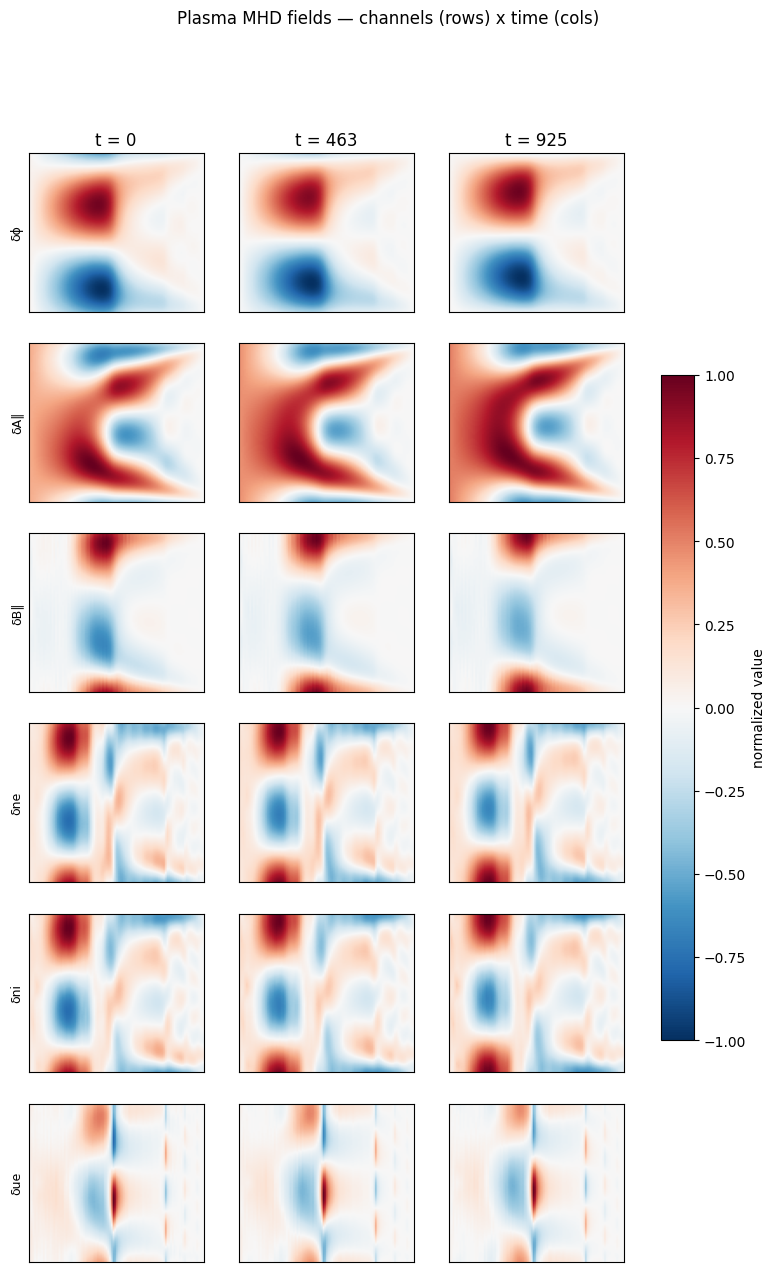

In [4]:
times = [0, T // 2, T - 1]
fig, axes = plt.subplots(C, len(times), figsize=(3.2 * len(times), 2.4 * C))
for c in range(C):
    for j, t in enumerate(times):
        ax = axes[c, j]
        im = ax.imshow(train[t, c], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        if c == 0:
            ax.set_title(f"t = {t}")
        if j == 0:
            ax.set_ylabel(CHANNEL_NAMES[c].split()[0], fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="normalized value")
fig.suptitle("Plasma MHD fields — channels (rows) x time (cols)")
plt.show()

## 5. Temporal evolution

Linear gyrokinetic modes oscillate. These plots show, per channel, the per-frame **spatial mean**
and **RMS amplitude** over the trajectory, plus a single-pixel time series — revealing the
oscillation period and whether amplitude grows/saturates over the window.


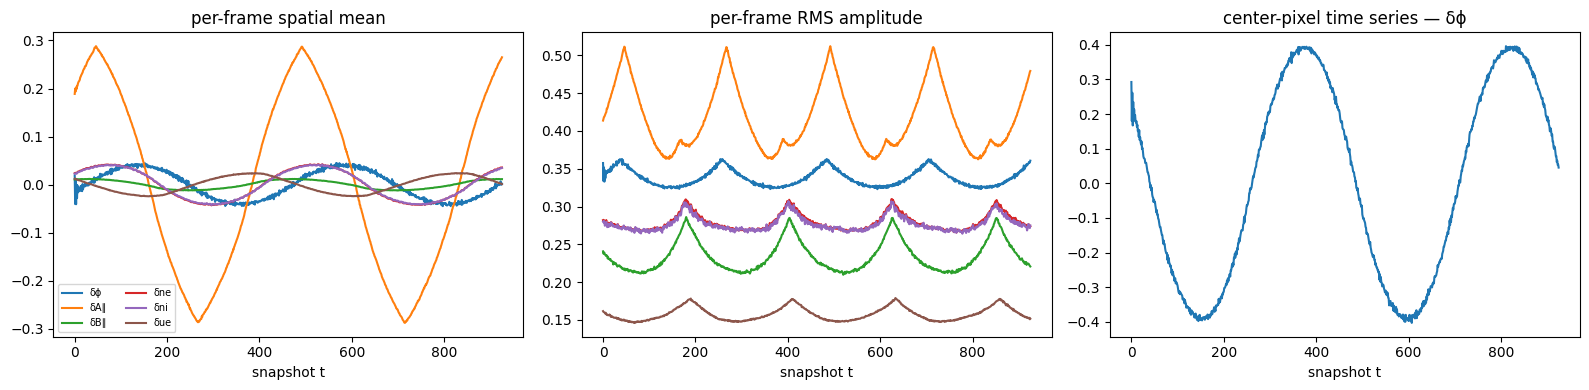

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c in range(C):
    fm = train[:, c].mean(axis=(1, 2))                 # spatial mean per frame
    rms = np.sqrt((train[:, c] ** 2).mean(axis=(1, 2)))  # RMS amplitude per frame
    ax[0].plot(fm, label=CHANNEL_NAMES[c].split()[0])
    ax[1].plot(rms, label=CHANNEL_NAMES[c].split()[0])
ax[0].set_title("per-frame spatial mean"); ax[0].set_xlabel("snapshot t")
ax[1].set_title("per-frame RMS amplitude"); ax[1].set_xlabel("snapshot t")
# single representative pixel (center) over time, channel 0
ax[2].plot(train[:, 0, H // 2, W // 2])
ax[2].set_title(f"center-pixel time series — {CHANNEL_NAMES[0].split()[0]}")
ax[2].set_xlabel("snapshot t")
ax[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 6. Value distributions

Histograms per channel. Peaked-near-zero with [−1, 1] support is expected; heavy tails or
saturation at ±1 (clipping) would matter for loss behavior.


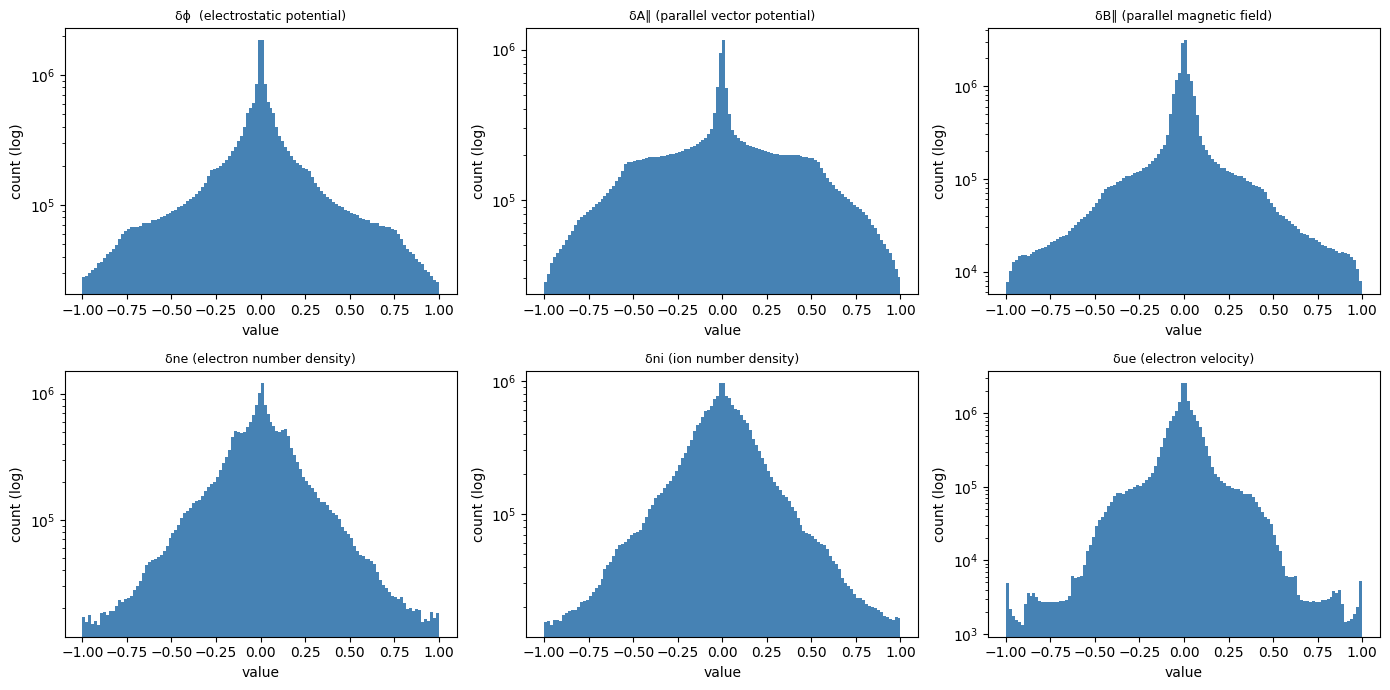

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for c in range(C):
    ax = axes[c // 3, c % 3]
    ax.hist(train[:, c].ravel(), bins=120, color="steelblue", log=True)
    ax.set_title(CHANNEL_NAMES[c], fontsize=9)
    ax.set_xlabel("value"); ax.set_ylabel("count (log)")
plt.tight_layout(); plt.show()

## 7. Spatial frequency content (why the model uses Fourier modes)

StFT keeps only the lowest `modes = (8, 8)` Fourier coefficients in each patch. This plot shows
the **time-averaged 2-D power spectrum** per channel (log scale). If energy is concentrated in the
lowest wavenumbers, retaining `(8, 8)` modes is well justified; energy beyond mode 8 is what the
Fourier path discards (the spatial-domain path must recover it).


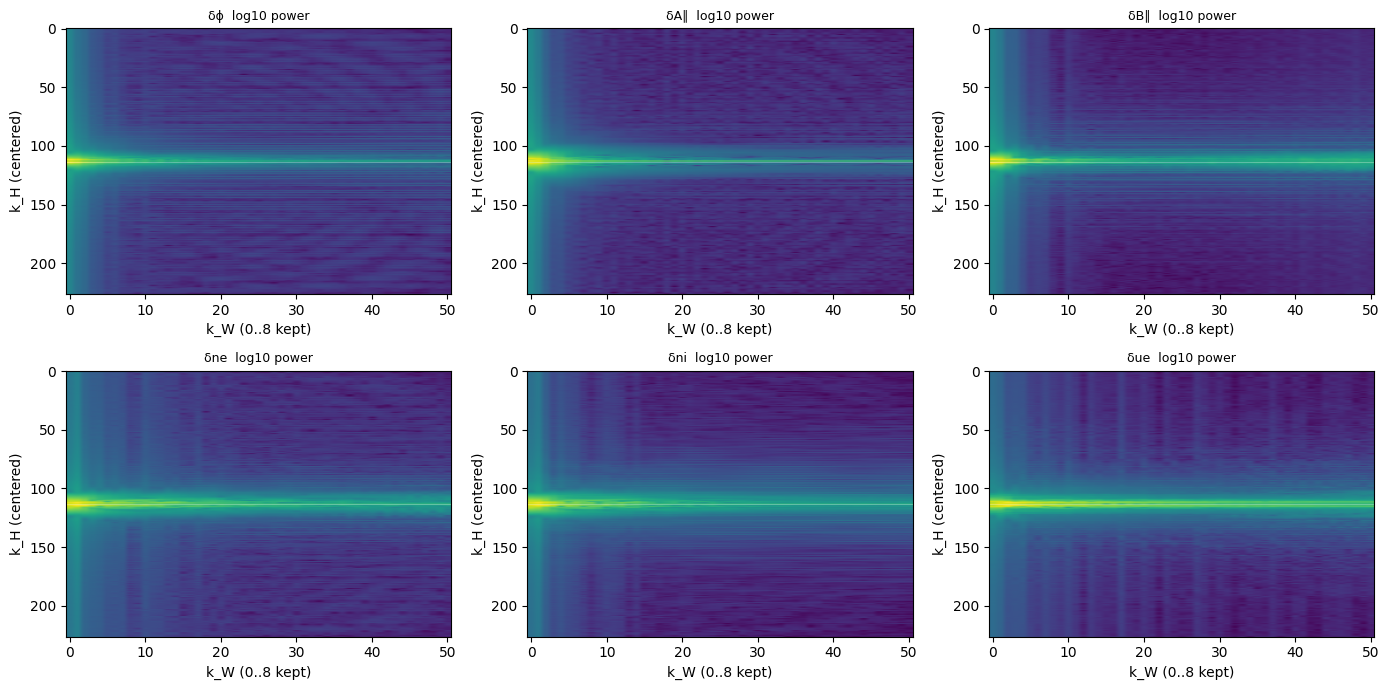

Model retains modes=(8,8); W has 51 rfft bins, H has 227 bins.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for c in range(C):
    ax = axes[c // 3, c % 3]
    # time-averaged power spectrum (rfft along W, full fft along H)
    F = np.fft.rfftn(train[:, c], axes=(1, 2))
    P = (np.abs(F) ** 2).mean(axis=0)
    P = np.fft.fftshift(P, axes=0)  # center the H axis
    ax.imshow(np.log10(P + 1e-12), cmap="viridis", aspect="auto")
    ax.axhline(P.shape[0] / 2, color="w", lw=0.4, alpha=0.5)
    ax.set_title(CHANNEL_NAMES[c].split()[0] + "  log10 power", fontsize=9)
    ax.set_xlabel("k_W (0..8 kept)"); ax.set_ylabel("k_H (centered)")
plt.tight_layout(); plt.show()
print("Model retains modes=(8,8); W has", train.shape[3] // 2 + 1, "rfft bins, H has", train.shape[2], "bins.")

## 8. Inter-channel correlations

The six variables are physically **coupled**. This correlation matrix (over all space-time samples)
shows how strongly channels co-vary — relevant because StFT predicts all channels jointly.


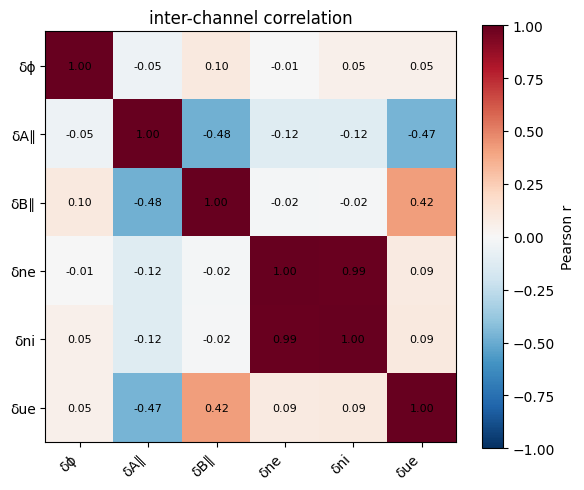

In [8]:
flat = train.reshape(T, C, -1).transpose(1, 0, 2).reshape(C, -1)  # (C, T*H*W)
corr = np.corrcoef(flat)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(C)); ax.set_yticks(range(C))
labs = [n.split()[0] for n in CHANNEL_NAMES]
ax.set_xticklabels(labs, rotation=45, ha="right"); ax.set_yticklabels(labs)
for i in range(C):
    for j in range(C):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="Pearson r"); ax.set_title("inter-channel correlation")
plt.tight_layout(); plt.show()

## 9. Modeling implications (tie-back to StFT config)

- **Single trajectory (`N=1`).** Only one realization → the data loader yields one sample per epoch,
  and the model can memorize it (the train-down / val-flat behavior we saw). More trajectories would
  be the real fix; with one, val error is the metric to watch, not train loss.
- **Patch sizes vs field size.** `patch_sizes = ((128,128),(64,64))` against a `227 × 101` field: the
  level-0 patch (128) exceeds `W=101`, so it's padded — level-0 is essentially global, level-1 (64) is
  the finer local scale. Check Section 4/7 to see whether structure is fine enough to warrant a third scale.
- **Fourier modes vs spectrum.** `modes=(8,8)` keeps only the lowest 8×8 wavenumbers per patch.
  Section 7 shows how much energy lives beyond that (handled by the spatial-domain path).
- **Normalization.** Data is already [−1,1]; training applies a further per-channel z-score. Channels
  with smaller std (ch2, ch5) contribute less raw magnitude to the L2 loss before that rescaling.
- **Autoregression.** `cond_time=5` past frames predict the next; Section 5's oscillation period tells
  you whether 5 frames span a meaningful fraction of a mode cycle.
